# MACD 指标计算与绘图测试 (交互式版本)

使用三花智控 (002050.SZ) 股票数据绘制 MACD 图

**数据来源**: 本地 SQLite 数据库 (data/market.db)

## 1. 环境准备

In [1]:
import sys
import os
import sqlite3
from datetime import datetime, timedelta
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

# 设置 matplotlib 在 notebook 中内联显示
%matplotlib inline

# 添加项目路径
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'src'))

print(f"项目根目录: {project_root}")

项目根目录: /data/workspace/tmp/cloakscn.github.io/private/quant-macd


## 2. 加载 MACD 策略模块

In [2]:
from src.strategy.macd import MACDStrategy

# 创建策略实例
strategy = MACDStrategy()

print("MACD 策略参数:")
for key, value in strategy.params.items():
    print(f"  {key}: {value}")

MACD 策略参数:
  fast_period: 12
  slow_period: 26
  signal_period: 9
  volume_confirm: True
  volume_ratio: 1.5
  min_data_length: 60


## 3. 从本地数据库加载数据

In [3]:
# 配置
LOCAL_DB_FILE = project_root / 'data' / 'market.db'
symbol = "002050.SZ"  # 三花智控
symbol_name = "三花智控"

# 检查数据库文件
if not LOCAL_DB_FILE.exists():
    raise FileNotFoundError(f"数据库文件不存在: {LOCAL_DB_FILE}")

print(f"正在从本地数据库加载 {symbol_name} ({symbol}) 数据...")
print(f"数据库文件: {LOCAL_DB_FILE}")

正在从本地数据库加载 三花智控 (002050.SZ) 数据...
数据库文件: /data/workspace/tmp/cloakscn.github.io/private/quant-macd/data/market.db


In [4]:
# 读取数据
conn = sqlite3.connect(str(LOCAL_DB_FILE))
query = f"SELECT * FROM ohlcv WHERE symbol = '{symbol}' ORDER BY date"
data = pd.read_sql_query(query, conn)
conn.close()

# 转换日期列类型
data['date'] = pd.to_datetime(data['date'])

print(f"✅ 加载到 {len(data)} 条数据")
print(f"时间范围: {data['date'].min().strftime('%Y-%m-%d')} ~ {data['date'].max().strftime('%Y-%m-%d')}")
print()
print("数据预览:")
data.tail()

✅ 加载到 242 条数据
时间范围: 2025-03-03 ~ 2026-03-02

数据预览:


,symbol,date,open,high,low,close,volume,amount
237,002050.SZ,2026-02-24,55.02,55.02,52.36,52.73,142644407,7.576283e+09
238,002050.SZ,2026-02-25,52.74,52.80,51.30,52.15,130654584,6.770429e+09
239,002050.SZ,2026-02-26,51.80,52.50,51.37,51.94,98106760,5.089017e+09
240,002050.SZ,2026-02-27,51.68,51.93,51.12,51.21,91569484,4.698512e+09
241,002050.SZ,2026-03-02,49.90,50.46,49.36,49.40,130220873,6.472252e+09


## 4. 测试: 计算 MACD 指标

In [5]:
# 计算指标
df = strategy.calculate_indicators(data.copy())

# 验证新增列存在
expected_columns = ['ema_fast', 'ema_slow', 'macd', 'signal', 'histogram', 
                    'volume_ma', 'volume_ratio', 'macd_cross']

print("检查计算结果:")
for col in expected_columns:
    exists = col in df.columns
    status = "✅" if exists else "❌"
    print(f"  {status} {col}: {'存在' if exists else '缺失'}")

# 验证数据非空
print()
print("数据完整性检查:")
print(f"  MACD 非空: {not df['macd'].isna().all()}")
print(f"  Signal 非空: {not df['signal'].isna().all()}")

检查计算结果:
  ✅ ema_fast: 存在
  ✅ ema_slow: 存在
  ✅ macd: 存在
  ✅ signal: 存在
  ✅ histogram: 存在
  ✅ volume_ma: 存在
  ✅ volume_ratio: 存在
  ✅ macd_cross: 存在

数据完整性检查:
  MACD 非空: True
  Signal 非空: True


In [6]:
# 查看最新指标值
print("最新指标值:")
print(f"  日期: {df['date'].iloc[-1].strftime('%Y-%m-%d')}")
print(f"  收盘价: ¥{df['close'].iloc[-1]:.2f}")
print(f"  MACD (DIF): {df['macd'].iloc[-1]:.4f}")
print(f"  Signal (DEA): {df['signal'].iloc[-1]:.4f}")
print(f"  Histogram (柱状图): {df['histogram'].iloc[-1]:.4f}")
print(f"  成交量比: {df['volume_ratio'].iloc[-1]:.2f}")

最新指标值:
  日期: 2026-03-02
  收盘价: ¥49.40
  MACD (DIF): -0.2498
  Signal (DEA): 0.0489
  Histogram (柱状图): -0.5975
  成交量比: 0.97


In [7]:
# 查看计算后的数据
df[['date', 'close', 'ema_fast', 'ema_slow', 'macd', 'signal', 'histogram', 'macd_cross']].tail(10)

,date,close,ema_fast,ema_slow,macd,signal,histogram,macd_cross
232,2026-02-09,51.58,51.934391,52.062634,-0.128243,0.465898,-1.188281,0
233,2026-02-10,53.30,52.144485,52.154291,-0.009806,0.370757,-0.761126,0
234,2026-02-11,52.16,52.146872,52.154714,-0.007842,0.295037,-0.605758,0
235,2026-02-12,52.67,52.227353,52.192883,0.034470,0.242924,-0.416907,0
236,2026-02-13,53.48,52.420068,52.288225,0.131843,0.220707,-0.177729,0
237,2026-02-24,52.73,52.467750,52.320949,0.146801,0.205926,-0.118251,0
238,2026-02-25,52.15,52.418865,52.308286,0.110579,0.186857,-0.152555,0
239,2026-02-26,51.94,52.345194,52.281006,0.064188,0.162323,-0.196270,0
240,2026-02-27,51.21,52.170548,52.201672,-0.031124,0.123634,-0.309514,0
241,2026-03-02,49.40,51.744310,51.994141,-0.249831,0.048941,-0.597543,0


## 5. 测试: 绘制 MACD 图表

这是最重要的可视化部分，你可以直接在 notebook 中看到图表！

/data/workspace/tmp/cloakscn.github.io/private/quant-macd/venv/lib64/python3.6/site-packages/ipykernel_launcher.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/data/workspace/tmp/cloakscn.github.io/private/quant-macd/venv/lib64/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 19977 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/data/workspace/tmp/cloakscn.github.io/private/quant-macd/venv/lib64/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 33457 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/data/workspace/tmp/cloakscn.github.io/private/quant-macd/venv/lib64/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 26234 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/data/workspace/tmp/cloakscn.github.io/private/quant-macd/venv/lib64/python3.6/site-packages

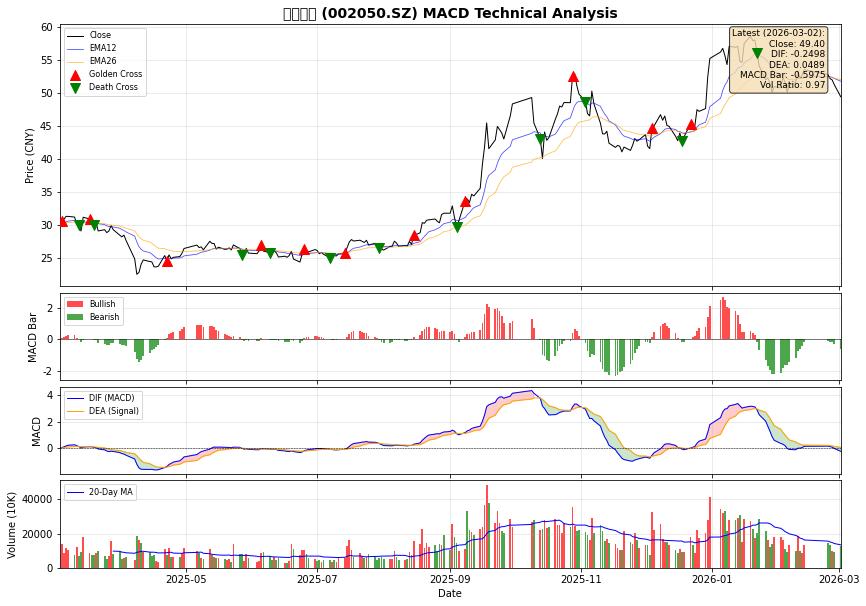


✅ 图表绘制完成！


In [8]:
# 创建图形
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(4, 1, height_ratios=[3, 1, 1, 1], hspace=0.05)

# 设置字体
plt.rcParams['axes.unicode_minus'] = False

# 子图1: K线图 + EMA
ax1 = fig.add_subplot(gs[0])
ax1.set_title(f'{symbol_name} ({symbol}) MACD Technical Analysis', fontsize=14, fontweight='bold')

# 绘制收盘价
ax1.plot(df['date'], df['close'], label='Close', color='black', linewidth=1)
ax1.plot(df['date'], df['ema_fast'], label=f'EMA{strategy.params["fast_period"]}', 
         color='blue', linewidth=0.8, alpha=0.7)
ax1.plot(df['date'], df['ema_slow'], label=f'EMA{strategy.params["slow_period"]}', 
         color='orange', linewidth=0.8, alpha=0.7)

# 标记金叉死叉
golden_cross = df[df['macd_cross'] == 1]
death_cross = df[df['macd_cross'] == -1]

ax1.scatter(golden_cross['date'], golden_cross['close'], 
           marker='^', color='red', s=100, label='Golden Cross', zorder=5)
ax1.scatter(death_cross['date'], death_cross['close'], 
           marker='v', color='green', s=100, label='Death Cross', zorder=5)

ax1.set_ylabel('Price (CNY)')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(df['date'].min(), df['date'].max())

# 子图2: MACD 柱状图
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# 分离正负柱
positive = df['histogram'] >= 0
negative = df['histogram'] < 0

ax2.bar(df.loc[positive, 'date'], df.loc[positive, 'histogram'], 
       color='red', alpha=0.7, width=0.8, label='Bullish')
ax2.bar(df.loc[negative, 'date'], df.loc[negative, 'histogram'], 
       color='green', alpha=0.7, width=0.8, label='Bearish')

ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_ylabel('MACD Bar')
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)

# 子图3: MACD 线
ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.plot(df['date'], df['macd'], label='DIF (MACD)', color='blue', linewidth=1)
ax3.plot(df['date'], df['signal'], label='DEA (Signal)', color='orange', linewidth=1)
ax3.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax3.fill_between(df['date'], df['macd'], df['signal'], 
                where=(df['macd'] >= df['signal']), 
                color='red', alpha=0.2)
ax3.fill_between(df['date'], df['macd'], df['signal'], 
                where=(df['macd'] < df['signal']), 
                color='green', alpha=0.2)
ax3.set_ylabel('MACD')
ax3.legend(loc='upper left', fontsize=8)
ax3.grid(True, alpha=0.3)

# 子图4: 成交量
ax4 = fig.add_subplot(gs[3], sharex=ax1)

# 根据涨跌着色
colors = ['red' if df['close'].iloc[i] >= df['open'].iloc[i] else 'green' 
         for i in range(len(df))]
ax4.bar(df['date'], df['volume'] / 10000, color=colors, alpha=0.7, width=0.8)
ax4.plot(df['date'], df['volume_ma'] / 10000, color='blue', linewidth=1, 
        label='20-Day MA')
ax4.set_ylabel('Volume (10K)')
ax4.set_xlabel('Date')
ax4.legend(loc='upper left', fontsize=8)
ax4.grid(True, alpha=0.3)

# 格式化 x 轴日期
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.setp(ax3.get_xticklabels(), visible=False)

# 添加统计信息
last_row = df.iloc[-1]
stats_text = (
    f"Latest ({last_row['date'].strftime('%Y-%m-%d')}):\n"
    f"Close: {last_row['close']:.2f}\n"
    f"DIF: {last_row['macd']:.4f}\n"
    f"DEA: {last_row['signal']:.4f}\n"
    f"MACD Bar: {last_row['histogram']:.4f}\n"
    f"Vol Ratio: {last_row['volume_ratio']:.2f}"
)

# 在右上角添加文本框
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax1.text(0.98, 0.98, stats_text, transform=ax1.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right', bbox=props)

# 调整布局
plt.tight_layout()
plt.show()

print("\n✅ 图表绘制完成！")

## 6. 测试: 金叉死叉统计

In [9]:
golden_crosses = df[df['macd_cross'] == 1]
death_crosses = df[df['macd_cross'] == -1]

print(f"=== {symbol_name} 金叉死叉统计 ===")
print(f"金叉次数: {len(golden_crosses)}")
print(f"死叉次数: {len(death_crosses)}")

=== 三花智控 金叉死叉统计 ===
金叉次数: 11
死叉次数: 11


In [10]:
# 最近金叉
print("最近 5 次金叉:")
if not golden_crosses.empty:
    for _, row in golden_crosses.tail(5).iterrows():
        print(f"  📈 {row['date'].strftime('%Y-%m-%d')} - 收盘价: ¥{row['close']:.2f}")
else:
    print("  无金叉记录")

最近 5 次金叉:
  📈 2025-08-15 - 收盘价: ¥28.47
  📈 2025-09-08 - 收盘价: ¥33.70
  📈 2025-10-28 - 收盘价: ¥52.49
  📈 2025-12-04 - 收盘价: ¥44.69
  📈 2025-12-22 - 收盘价: ¥45.32


In [11]:
# 最近死叉
print("最近 5 次死叉:")
if not death_crosses.empty:
    for _, row in death_crosses.tail(5).iterrows():
        print(f"  📉 {row['date'].strftime('%Y-%m-%d')} - 收盘价: ¥{row['close']:.2f}")
else:
    print("  无死叉记录")

最近 5 次死叉:
  📉 2025-09-04 - 收盘价: ¥29.72
  📉 2025-10-13 - 收盘价: ¥43.07
  📉 2025-11-03 - 收盘价: ¥48.68
  📉 2025-12-18 - 收盘价: ¥42.79
  📉 2026-01-22 - 收盘价: ¥56.03


In [12]:
# 金叉死叉详细表格
print("\n金叉记录:")
golden_crosses[['date', 'close', 'macd', 'signal', 'histogram']].tail(10)


金叉记录:


,date,close,macd,signal,histogram
10,2025-03-17,30.951062,0.104346,0.097577,0.013539
35,2025-04-22,24.624432,-1.391296,-1.441292,0.099992
63,2025-06-05,27.030754,-0.042364,-0.066818,0.048909
77,2025-06-25,26.432066,-0.200243,-0.232335,0.064184
90,2025-07-14,25.813422,-0.097201,-0.111010,0.027618
114,2025-08-15,28.467605,0.287384,0.221433,0.131900
130,2025-09-08,33.696145,1.166915,1.108371,0.117088
160,2025-10-28,52.494942,3.100228,2.899522,0.401411
187,2025-12-04,44.692044,-0.553883,-0.636876,0.165986
199,2025-12-22,45.320666,0.002228,-0.017967,0.040390


## 7. 额外: 自定义时间范围分析

In [13]:
# 你可以修改这里的日期来分析特定时间段
start_date = '2024-01-01'
end_date = '2024-12-31'

# 筛选数据
df_filtered = df[(df['date'] >= start_date) & (df['date'] <= end_date)].copy()

print(f"筛选时间段: {start_date} ~ {end_date}")
print(f"数据条数: {len(df_filtered)}")

if len(df_filtered) > 0:
    # 这个时间段的金叉死叉
    golden = df_filtered[df_filtered['macd_cross'] == 1]
    death = df_filtered[df_filtered['macd_cross'] == -1]
    print(f"该时段金叉: {len(golden)} 次")
    print(f"该时段死叉: {len(death)} 次")

筛选时间段: 2024-01-01 ~ 2024-12-31
数据条数: 0


In [14]:
# 绘制筛选时段的简化图
if len(df_filtered) > 10:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    
    # 价格图
    ax1.plot(df_filtered['date'], df_filtered['close'], 'k-', label='Close')
    ax1.set_ylabel('Price')
    ax1.set_title(f'{symbol_name} ({start_date} ~ {end_date})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 标记金叉死叉
    golden = df_filtered[df_filtered['macd_cross'] == 1]
    death = df_filtered[df_filtered['macd_cross'] == -1]
    ax1.scatter(golden['date'], golden['close'], marker='^', c='red', s=100, label='Golden')
    ax1.scatter(death['date'], death['close'], marker='v', c='green', s=100, label='Death')
    
    # MACD
    ax2.plot(df_filtered['date'], df_filtered['macd'], 'b-', label='DIF')
    ax2.plot(df_filtered['date'], df_filtered['signal'], 'orange', label='DEA')
    ax2.axhline(0, color='gray', linestyle='--')
    ax2.set_ylabel('MACD')
    ax2.set_xlabel('Date')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("数据太少，无法绘图")

数据太少，无法绘图


## 8. 测试总结

运行完所有单元格后，你应该能看到：

1. ✅ MACD 指标计算正确
2. ✅ 图表正常显示（价格、MACD柱、MACD线、成交量）
3. ✅ 金叉死叉被正确识别和标记

这比直接运行 `unittest` 更直观，因为你可以：
- 逐步执行，观察每一步的结果
- 直接在 notebook 中看到图表
- 修改参数后立即重新运行
- 添加自己的分析代码